In [17]:
import pandas as pd
#para que salgan todas las columnas display max
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/csv/df_merged.csv')

In [2]:
df.head()

,date,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,FearGreed_Label,inflation,btc_mcap,eth_mcap,fed_rate
0,2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9959400448,1119.369995,1161.349976,984.818970,1036.790039,5261680128,0.334251,0.211308,0.454441,30.0,Fear,2.263469,1.703042e+11,1.076635e+11,1.42
1,2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,12726899712,1035.770020,1035.770020,757.979980,915.784973,6713290240,0.339622,0.221066,0.439312,15.0,Extreme Fear,2.263469,1.527442e+11,9.942376e+10,1.42
2,2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7263790080,919.210999,991.942993,847.690002,964.018982,3243480064,0.350252,0.209758,0.439990,40.0,Fear,2.263469,1.487152e+11,8.906186e+10,1.42
3,2018-02-04,9175.700195,9334.870117,8031.220215,8277.009766,7073549824,964.666992,969.031982,805.064026,834.682007,2997090048,0.341270,0.206612,0.452118,24.0,Extreme Fear,2.263469,1.515073e+11,9.172561e+10,1.42
4,2018-02-05,8270.540039,8364.839844,6756.680176,6955.270020,9285289984,834.958008,856.645996,644.598999,697.950989,4269530112,0.351816,0.204261,0.443923,11.0,Extreme Fear,2.263469,1.400815e+11,8.132982e+10,1.42


In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from datetime import datetime

print("=" * 80)
print("AGREGACIÓN MENSUAL CON FEATURE ENGINEERING")
print("=" * 80)

# Cargar el df que ya tenemos
# df = pd.read_csv(r"C:\Users\josit\...\df_2018_2025.csv", parse_dates=['date'])

# PASO 1: ONE-HOT ENCODER para Fear & Greed Label
print("\n🔴 1. One-Hot Encoding Fear & Greed Label...")

# Crear mapping si la columna se llama diferente
if 'FearGreed_Label' in df.columns:
    fear_col = 'FearGreed_Label'
elif 'fear_greed_label' in df.columns:
    fear_col = 'fear_greed_label'
else:
    fear_col = [col for col in df.columns if 'label' in col.lower()][0]

# One-Hot Encoding con 0s y 1s (no True/False)

fear_encoded = pd.get_dummies(df[fear_col], prefix='fear')

# Convertir a int (0 y 1) en lugar de bool (True/False)
fear_encoded = fear_encoded.astype(int)

df_sorted = pd.concat([df, fear_encoded], axis=1)


AGREGACIÓN MENSUAL CON FEATURE ENGINEERING

🔴 1. One-Hot Encoding Fear & Greed Label...


In [25]:
df_sorted

,date,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,FearGreed_Label,inflation,btc_mcap,eth_mcap,fed_rate,fear_Extreme Fear,fear_Extreme Greed,fear_Fear,fear_Greed,fear_Neutral
0,2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9959400448,1119.369995,1161.349976,984.818970,1036.790039,5261680128,0.334251,0.211308,0.454441,30.0,Fear,2.263469,1.703042e+11,1.076635e+11,1.42,0,0,1,0,0
1,2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,12726899712,1035.770020,1035.770020,757.979980,915.784973,6713290240,0.339622,0.221066,0.439312,15.0,Extreme Fear,2.263469,1.527442e+11,9.942376e+10,1.42,1,0,0,0,0
2,2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7263790080,919.210999,991.942993,847.690002,964.018982,3243480064,0.350252,0.209758,0.439990,40.0,Fear,2.263469,1.487152e+11,8.906186e+10,1.42,0,0,1,0,0
3,2018-02-04,9175.700195,9334.870117,8031.220215,8277.009766,7073549824,964.666992,969.031982,805.064026,834.682007,2997090048,0.341270,0.206612,0.452118,24.0,Extreme Fear,2.263469,1.515073e+11,9.172561e+10,1.42,1,0,0,0,0
4,2018-02-05,8270.540039,8364.839844,6756.680176,6955.270020,9285289984,834.958008,856.645996,644.598999,697.950989,4269530112,0.351816,0.204261,0.443923,11.0,Extreme Fear,2.263469,1.400815e+11,8.132982e+10,1.42,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2880,2025-12-21,88344.703125,89027.953125,87613.203125,88621.750000,19845522660,2977.508545,3009.807129,2945.394775,3001.613770,11178096676,0.572387,0.116629,0.310984,20.0,Extreme Fear,2.700000,1.762805e+12,3.591869e+11,3.84,1,0,0,0,0
2881,2025-12-22,88621.398438,90501.929688,87908.070312,88490.015625,38047472118,3001.612793,3073.353760,2965.175049,3006.073730,20342034264,0.573053,0.117441,0.309506,25.0,Extreme Fear,2.700000,1.768920e+12,3.625196e+11,3.84,1,0,0,0,0
2882,2025-12-23,88490.031250,88898.382812,86606.976562,87414.000000,43683011533,3006.073975,3033.196289,2902.333008,2963.374023,21453213168,0.573204,0.117729,0.309067,24.0,Extreme Fear,2.700000,1.767081e+12,3.629357e+11,3.84,1,0,0,0,0
2883,2025-12-24,87404.320312,87956.882812,86411.796875,87611.960938,25550297986,2962.922607,2975.171143,2888.988037,2945.590576,13984770325,0.573230,0.117515,0.309256,24.0,Extreme Fear,2.700000,1.745209e+12,3.577764e+11,3.84,1,0,0,0,0


KALMAN FILTER - ANÁLISIS ANTES Y DESPUÉS

📈 PARTE 1: Gráfica ANTES (Precios originales sin filtro)...


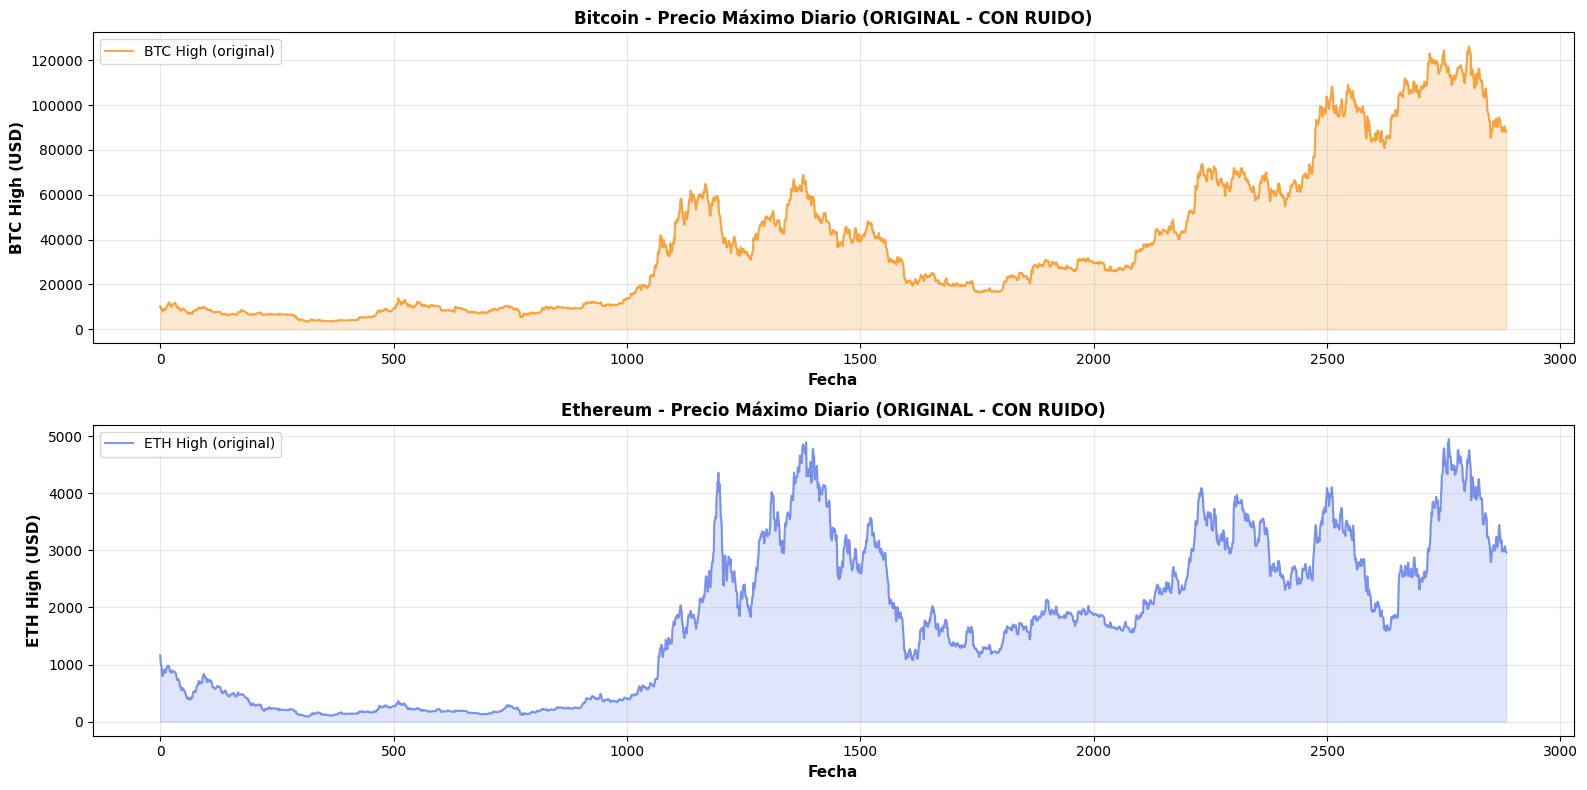

In [31]:

print("=" * 80)
print("KALMAN FILTER - ANÁLISIS ANTES Y DESPUÉS")
print("=" * 80)

# Cargar df_sorted (ya tienes)
# df_sorted = ...

print("\n📈 PARTE 1: Gráfica ANTES (Precios originales sin filtro)...")

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Gráfico 1: BTC High
ax1 = axes[0]
ax1.plot(df_sorted.index, df_sorted['btc_high'], label='BTC High (original)', 
         linewidth=1.5, alpha=0.8, color='#F7931A')
ax1.fill_between(df_sorted.index, df_sorted['btc_high'], alpha=0.2, color='#F7931A')
ax1.set_xlabel('Fecha', fontsize=11, fontweight='bold')
ax1.set_ylabel('BTC High (USD)', fontsize=11, fontweight='bold')
ax1.set_title('Bitcoin - Precio Máximo Diario (ORIGINAL - CON RUIDO)', 
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Gráfico 2: ETH High
ax2 = axes[1]
ax2.plot(df_sorted.index, df_sorted['eth_high'], label='ETH High (original)', 
         linewidth=1.5, alpha=0.8, color='#627EEA')
ax2.fill_between(df_sorted.index, df_sorted['eth_high'], alpha=0.2, color='#627EEA')
ax2.set_xlabel('Fecha', fontsize=11, fontweight='bold')
ax2.set_ylabel('ETH High (USD)', fontsize=11, fontweight='bold')
ax2.set_title('Ethereum - Precio Máximo Diario (ORIGINAL - CON RUIDO)', 
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [32]:
import numpy as np

print("\n🔧 PARTE 2: Aplicando Filtro Kalman...")

def kalman_filter_1d(data, process_variance=0.1, measurement_variance=1.0):
    """
    Filtro Kalman simple 1D para suavizar series temporales
    
    Parameters:
    -----------
    data: array de valores
    process_variance: qué tan rápido cambia el estado real (bajo = más suave)
    measurement_variance: ruido en las mediciones (bajo = confía más en datos)
    
    Returns:
    --------
    filtered: array suavizado
    """
    filtered = np.zeros_like(data, dtype=float)
    x = float(data[0])  # Estado inicial
    p = 1.0  # Covarianza inicial
    
    for i, z in enumerate(data):
        # Predicción
        p_predict = p + process_variance
        
        # Actualización (Ganancia de Kalman)
        k = p_predict / (p_predict + measurement_variance)
        x = x + k * (float(z) - x)  # Corrección
        p = (1 - k) * p_predict
        
        filtered[i] = x
    
    return filtered

# Crear copias de seguridad (antes del filtro)
df_sorted_original = df_sorted.copy()

# Aplicar Kalman a BTC High/Low
print("   Filtrando BTC High...")
df_sorted['btc_high'] = kalman_filter_1d(df_sorted['btc_high'].values, 
                                          process_variance=0.001, 
                                          measurement_variance=1.0)

print("   Filtrando BTC Low...")
df_sorted['btc_low'] = kalman_filter_1d(df_sorted['btc_low'].values, 
                                         process_variance=0.001, 
                                         measurement_variance=1.0)

# Aplicar Kalman a ETH High/Low
print("   Filtrando ETH High...")
df_sorted['eth_high'] = kalman_filter_1d(df_sorted['eth_high'].values, 
                                          process_variance=0.001, 
                                          measurement_variance=1.0)

print("   Filtrando ETH Low...")
df_sorted['eth_low'] = kalman_filter_1d(df_sorted['eth_low'].values, 
                                         process_variance=0.001, 
                                         measurement_variance=1.0)

print(f"   ✅ Filtro Kalman aplicado a 4 columnas")



🔧 PARTE 2: Aplicando Filtro Kalman...
   Filtrando BTC High...
   Filtrando BTC Low...
   Filtrando ETH High...
   Filtrando ETH Low...
   ✅ Filtro Kalman aplicado a 4 columnas



📊 PARTE 3: Gráfica COMPARATIVA (Antes vs Después)...


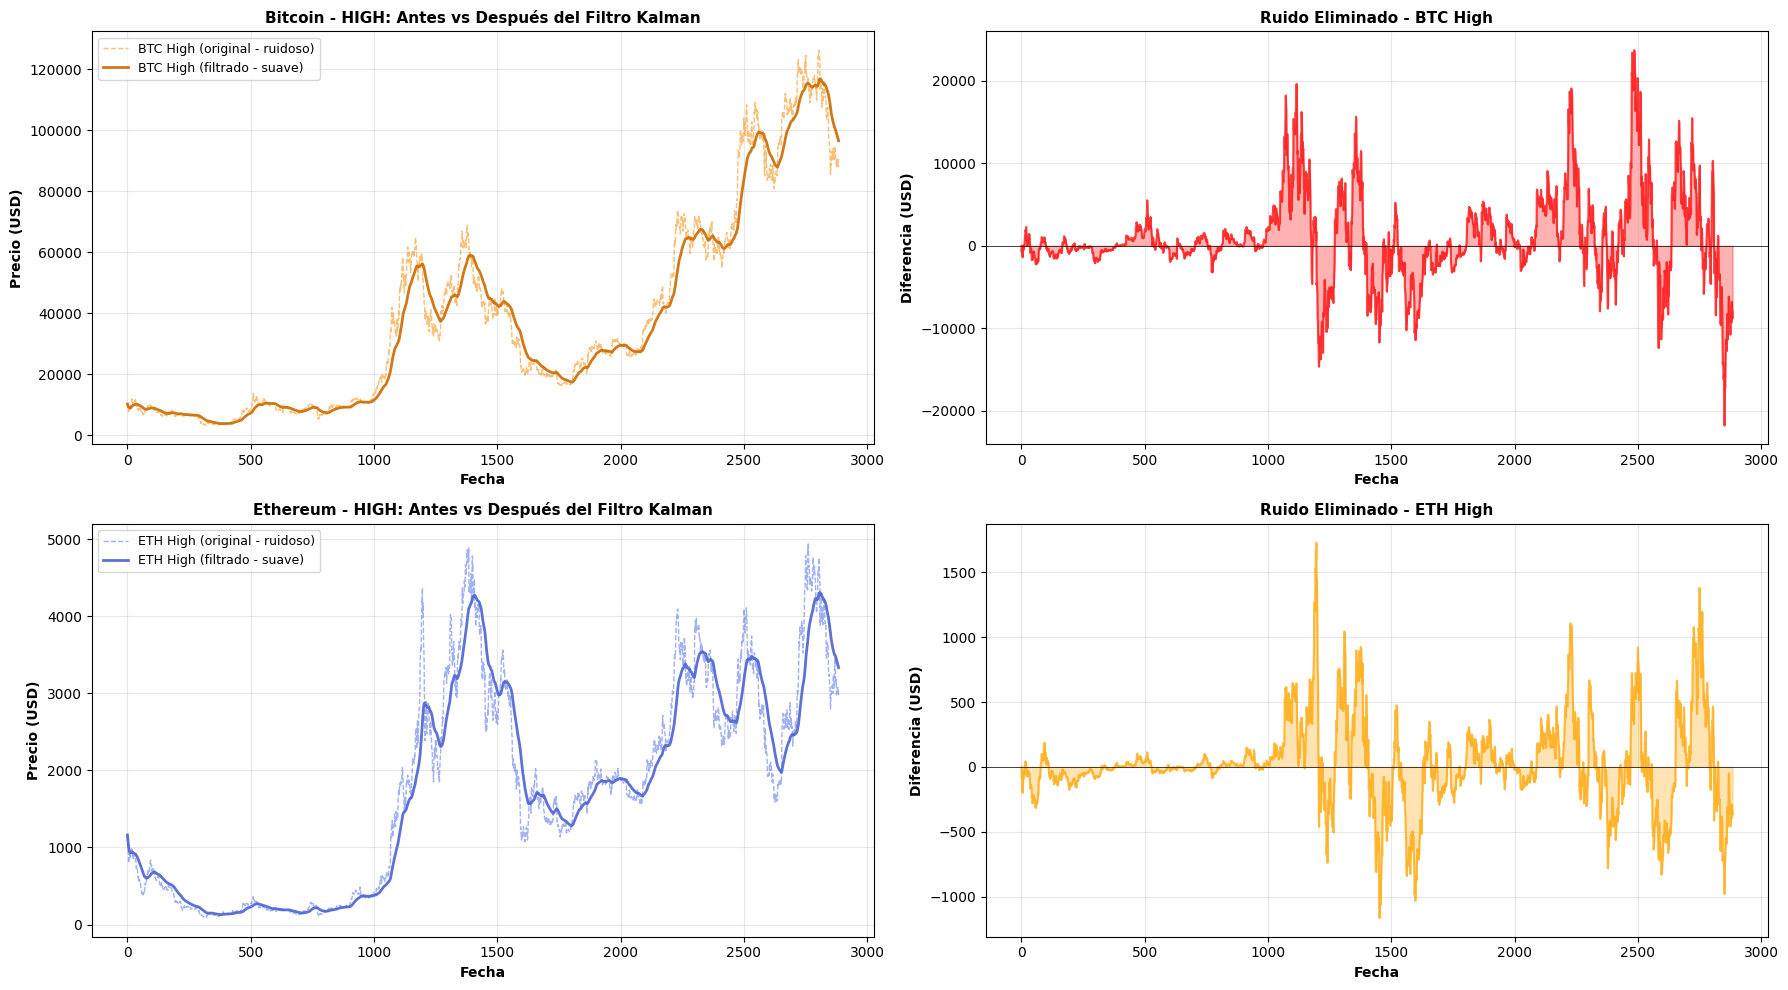


📊 Estadísticas del Filtrado:
   BTC High - Ruido promedio removido: $937.57
   BTC High - Ruido máximo removido: $23739.93
   ETH High - Ruido promedio removido: $25.77
   ETH High - Ruido máximo removido: $1729.42


In [33]:
print("\n📊 PARTE 3: Gráfica COMPARATIVA (Antes vs Después)...")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# ========== FILA 1: BTC HIGH ==========

# Gráfico 1a: BTC High (Antes y Después juntos)
ax1 = axes[0, 0]
ax1.plot(df_sorted_original.index, df_sorted_original['btc_high'], 
         label='BTC High (original - ruidoso)', linewidth=1, alpha=0.6, 
         color='#F7931A', linestyle='--')
ax1.plot(df_sorted.index, df_sorted['btc_high'], 
         label='BTC High (filtrado - suave)', linewidth=2, alpha=0.9, 
         color='#CC6B00')
ax1.set_xlabel('Fecha', fontsize=10, fontweight='bold')
ax1.set_ylabel('Precio (USD)', fontsize=10, fontweight='bold')
ax1.set_title('Bitcoin - HIGH: Antes vs Después del Filtro Kalman', 
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Gráfico 1b: Diferencia / Ruido removido (BTC High)
ax2 = axes[0, 1]
ruido_btc_high = df_sorted_original['btc_high'].values - df_sorted['btc_high'].values
ax2.plot(df_sorted.index, ruido_btc_high, label='Ruido removido (BTC High)', 
         linewidth=1.5, color='red', alpha=0.7)
ax2.fill_between(df_sorted.index, ruido_btc_high, alpha=0.3, color='red')
ax2.set_xlabel('Fecha', fontsize=10, fontweight='bold')
ax2.set_ylabel('Diferencia (USD)', fontsize=10, fontweight='bold')
ax2.set_title('Ruido Eliminado - BTC High', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# ========== FILA 2: ETH HIGH ==========

# Gráfico 2a: ETH High (Antes y Después juntos)
ax3 = axes[1, 0]
ax3.plot(df_sorted_original.index, df_sorted_original['eth_high'], 
         label='ETH High (original - ruidoso)', linewidth=1, alpha=0.6, 
         color='#627EEA', linestyle='--')
ax3.plot(df_sorted.index, df_sorted['eth_high'], 
         label='ETH High (filtrado - suave)', linewidth=2, alpha=0.9, 
         color='#4C63D2')
ax3.set_xlabel('Fecha', fontsize=10, fontweight='bold')
ax3.set_ylabel('Precio (USD)', fontsize=10, fontweight='bold')
ax3.set_title('Ethereum - HIGH: Antes vs Después del Filtro Kalman', 
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Gráfico 2b: Diferencia / Ruido removido (ETH High)
ax4 = axes[1, 1]
ruido_eth_high = df_sorted_original['eth_high'].values - df_sorted['eth_high'].values
ax4.plot(df_sorted.index, ruido_eth_high, label='Ruido removido (ETH High)', 
         linewidth=1.5, color='orange', alpha=0.7)
ax4.fill_between(df_sorted.index, ruido_eth_high, alpha=0.3, color='orange')
ax4.set_xlabel('Fecha', fontsize=10, fontweight='bold')
ax4.set_ylabel('Diferencia (USD)', fontsize=10, fontweight='bold')
ax4.set_title('Ruido Eliminado - ETH High', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# Estadísticas del filtrado
print("\n📊 Estadísticas del Filtrado:")
print(f"   BTC High - Ruido promedio removido: ${ruido_btc_high.mean():.2f}")
print(f"   BTC High - Ruido máximo removido: ${ruido_btc_high.max():.2f}")
print(f"   ETH High - Ruido promedio removido: ${ruido_eth_high.mean():.2f}")
print(f"   ETH High - Ruido máximo removido: ${ruido_eth_high.max():.2f}")


In [34]:
import torch

# Detectar si hay una GPU NVIDIA disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Entrenando en: {device}")

🚀 Entrenando en: cuda


In [35]:
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


print("=" * 80)
print("LSTM PARA PREDICCIÓN DE MERCADO CRYPTO")
print("=" * 80)


# Seleccionar features numéricos (excluir labels textuales)
features_to_use = [
    'btc_high', 'btc_low', 'btc_volume',
    'eth_high', 'eth_low', 'eth_volume',
    'btc_dominance', 'eth_dominance', 'alt_dominance',
    'fear_greed']

# Filtrar solo columnas que existan
features_to_use = [col for col in features_to_use if col in df_sorted.columns]

df_features = df_sorted[features_to_use].copy()

print(f"\n   Features usados: {len(features_to_use)}")
print(f"   Shape features: {df_features.shape}")

# Eliminar NaNs
df_features = df_features.dropna()

print(f"   Shape después de dropna: {df_features.shape}")


LSTM PARA PREDICCIÓN DE MERCADO CRYPTO

   Features usados: 10
   Shape features: (2885, 10)
   Shape después de dropna: (2885, 10)


In [36]:

# ============================================================================
# PASO 2: NORMALIZAR DATOS (CRÍTICO PARA LSTM)
# ============================================================================

print("\n🔧 PASO 2: Normalizando datos (MinMaxScaler)...")

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df_features)

print(f"   ✅ Datos normalizados [0, 1]")



🔧 PASO 2: Normalizando datos (MinMaxScaler)...
   ✅ Datos normalizados [0, 1]


In [37]:

# ============================================================================
# PASO 3: CREAR SEQUENCES TEMPORALES
# ============================================================================

print("\n⏱️ PASO 3: Creando sequences (ventanas temporales)...")

def create_sequences(data, seq_length=30):
    """Crear sequences de 30 días para predecir el siguiente día"""
    X, y = [], []
    
    for i in range(len(data) - seq_length):
        # Input: últimos 30 días
        X.append(data[i:i+seq_length])
        # Output: día siguiente (precio close de BTC)
        y.append(data[i+seq_length, 3])  # índice 3 = btc_close
    
    return np.array(X), np.array(y)

SEQ_LENGTH = 90  # 90 días de historia
X, y = create_sequences(data_scaled, SEQ_LENGTH)

print(f"   Shape X: {X.shape}")
print(f"   Shape y: {y.shape}")
print(f"   Sequences creadas: {len(X)}")



⏱️ PASO 3: Creando sequences (ventanas temporales)...
   Shape X: (2795, 90, 10)
   Shape y: (2795,)
   Sequences creadas: 2795


In [38]:
# ============================================================================
# PASO 4: SPLIT TRAIN/TEST (85% TRAIN, 15% TEST)
# ============================================================================

print("\n📂 PASO 4: Dividiendo datos (85% TRAIN + 15% TEST)...")

# 85% train, 15% test
train_size = int(len(X) * 0.85)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print(f"   Train: {X_train.shape[0]} samples (85%)")
print(f"   Test:  {X_test.shape[0]} samples (15%)")

# ============================================================================
# PASO 5: CREAR DATALOADERS
# ============================================================================

print("\n🔄 PASO 5: Creando DataLoaders...")

# Convertir a tensores PyTorch
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# DataLoaders
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"   Train batches: {len(train_loader)}")
print(f"   Test batches:  {len(test_loader)}")



📂 PASO 4: Dividiendo datos (85% TRAIN + 15% TEST)...
   Train: 2375 samples (85%)
   Test:  420 samples (15%)

🔄 PASO 5: Creando DataLoaders...
   Train batches: 75
   Test batches:  14



🏗️ PASO 6: Creando arquitectura LSTM...
   ✅ Modelo LSTM creado
   Input features: 10
   Hidden size: 64
   Sequence length: 90 días
   Dropout: 0.2

⚙️ PASO 7: Configurando training...
   Device: cuda
   Learning Rate: 0.0005
   Early Stopping en TEST (patience: 125)
   Max Epochs: 1000

ENTRENANDO MODELO (85% TRAIN + TEST monitoring)...



c:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\env_TFG_DEF\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Epoch 1/1000 | Train Loss: 0.026893 | Test Loss: 0.173915 ✅ (MEJOR)
Epoch 2/1000 | Train Loss: 0.010155 | Test Loss: 0.049646 ✅ (MEJOR)
Epoch 3/1000 | Train Loss: 0.010355 | Test Loss: 0.047305 ✅ (MEJOR)
Epoch 4/1000 | Train Loss: 0.008583 | Test Loss: 0.008198 ✅ (MEJOR)
Epoch 5/1000 | Train Loss: 0.007359 | Test Loss: 0.021357 | Patience: 1/125
Epoch 6/1000 | Train Loss: 0.007423 | Test Loss: 0.005236 ✅ (MEJOR)
Epoch 7/1000 | Train Loss: 0.006765 | Test Loss: 0.012290 | Patience: 1/125
Epoch 8/1000 | Train Loss: 0.005917 | Test Loss: 0.020155 | Patience: 2/125
Epoch 9/1000 | Train Loss: 0.005929 | Test Loss: 0.039121 | Patience: 3/125
Epoch 10/1000 | Train Loss: 0.005280 | Test Loss: 0.015508 | Patience: 4/125
Epoch 11/1000 | Train Loss: 0.005085 | Test Loss: 0.007967 | Patience: 5/125
Epoch 12/1000 | Train Loss: 0.004649 | Test Loss: 0.004841 ✅ (MEJOR)
Epoch 13/1000 | Train Loss: 0.005799 | Test Loss: 0.005137 | Patience: 1/125
Epoch 14/1000 | Train Loss: 0.005276 | Test Loss: 0.0073

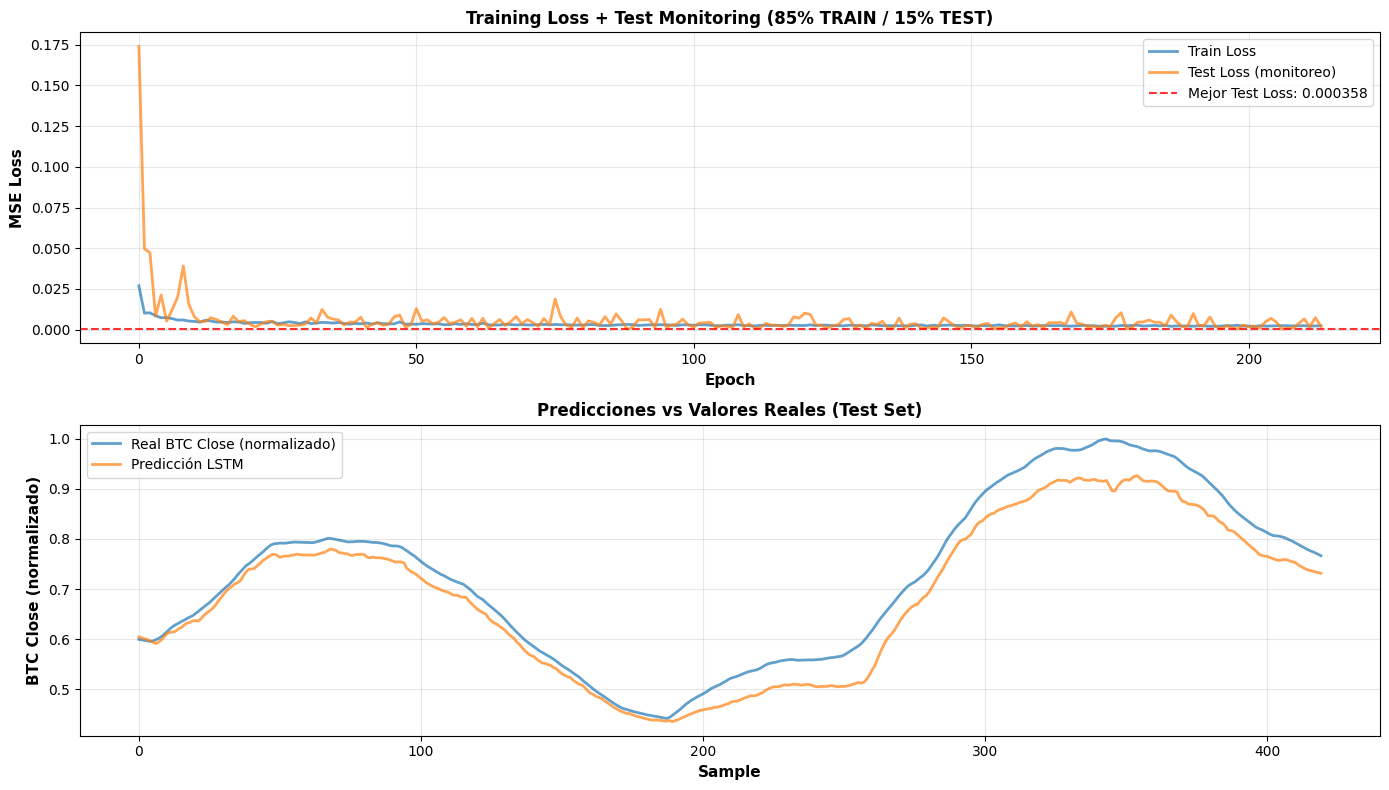


💾 PASO 11: Guardando modelo...
   ✅ Modelo guardado: lstm_85_train_90_seq.pth

✅ LSTM AJUSTADO COMPLETADO
   - 85% TRAIN + 15% TEST
   - Sequence length: 90 días
   - Early stopping en TEST


In [39]:
# ============================================================================
# PASO 6: DEFINIR ARQUITECTURA LSTM (SEQ_LENGTH=90)
# ============================================================================

print("\n🏗️ PASO 6: Creando arquitectura LSTM...")

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        
        self.lstm1 = nn.LSTM(input_size, hidden_size, num_layers=1, 
                            batch_first=True, dropout=dropout)
        self.lstm2 = nn.LSTM(hidden_size, hidden_size, num_layers=1, 
                            batch_first=True, dropout=dropout)
        
        self.batch_norm = nn.BatchNorm1d(hidden_size)
        
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 1)
    
    def forward(self, x):
        lstm_out1, _ = self.lstm1(x)
        lstm_out2, (h_n, c_n) = self.lstm2(lstm_out1)
        last_output = lstm_out2[:, -1, :]  # Último día de los 90
        
        bn_out = self.batch_norm(last_output)
        fc1_out = self.relu(self.fc1(bn_out))
        fc1_out = self.dropout(fc1_out)
        output = self.fc2(fc1_out)
        
        return output

# Instanciar modelo
input_size = X_train.shape[2]
model = LSTMModel(input_size=input_size, hidden_size=64, num_layers=2, dropout=0.2)

print(f"   ✅ Modelo LSTM creado")
print(f"   Input features: {input_size}")
print(f"   Hidden size: 64")
print(f"   Sequence length: 90 días")
print(f"   Dropout: 0.2")

# ============================================================================
# PASO 7: CONFIGURAR TRAINING
# ============================================================================

print("\n⚙️ PASO 7: Configurando training...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Optimizer
learning_rate = 0.0005  # Conservador para secuencias largas
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Loss function
criterion = nn.MSELoss()

# Early Stopping en TEST (en vez de val)
patience = 125
best_test_loss = float('inf')
patience_counter = 0
best_model_state = None

NUM_EPOCHS = 1000
print(f"   Device: {device}")
print(f"   Learning Rate: {learning_rate}")
print(f"   Early Stopping en TEST (patience: {patience})")
print(f"   Max Epochs: {NUM_EPOCHS}")

# ============================================================================
# PASO 8: TRAINING LOOP (MONITOREO EN TEST)
# ============================================================================

print("\n" + "=" * 80)
print("ENTRENANDO MODELO (85% TRAIN + TEST monitoring)...")
print("=" * 80 + "\n")

train_losses = []
test_losses = []

for epoch in range(NUM_EPOCHS):
    # TRAIN
    model.train()
    train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # TEST (monitoreo en cada epoch)
    model.eval()
    test_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            test_loss += loss.item()
    
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    
    # Early Stopping basado en TEST LOSS
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f} ✅ (MEJOR)")
    else:
        patience_counter += 1
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f} | Patience: {patience_counter}/{patience}")
    
    # Early Stopping trigger
    if patience_counter >= patience:
        print(f"\n⛔ EARLY STOPPING: Sin mejora en TEST durante {patience} epochs")
        model.load_state_dict(best_model_state)
        break

print("\n" + "=" * 80)
print("✅ ENTRENAMIENTO COMPLETADO")
print("=" * 80)

# ============================================================================
# PASO 9: RESULTADOS FINALES
# ============================================================================

print("\n📈 PASO 9: Resultados finales...")

print(f"   Final Train Loss: {train_losses[-1]:.6f}")
print(f"   Final Test Loss:  {test_losses[-1]:.6f}")
print(f"   Best Test Loss:   {best_test_loss:.6f}")
print(f"   Epochs usadas:    {len(train_losses)}")

# ============================================================================
# PASO 10: VISUALIZAR RESULTADOS
# ============================================================================

print("\n📊 PASO 10: Creando gráficos...")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Gráfico 1: Loss durante training
ax1 = axes[0]
ax1.plot(train_losses, label='Train Loss', linewidth=2, alpha=0.7)
ax1.plot(test_losses, label='Test Loss (monitoreo)', linewidth=2, alpha=0.7)
ax1.axhline(y=best_test_loss, color='red', linestyle='--', 
           label=f'Mejor Test Loss: {best_test_loss:.6f}', alpha=0.8)
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('MSE Loss', fontsize=11, fontweight='bold')
ax1.set_title('Training Loss + Test Monitoring (85% TRAIN / 15% TEST)', 
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Predicciones vs Reales (Test)
model.eval()
predictions = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch)
        predictions.extend(pred.cpu().numpy().flatten())

ax2 = axes[1]
ax2.plot(y_test, label='Real BTC Close (normalizado)', linewidth=2, alpha=0.7)
ax2.plot(predictions, label='Predicción LSTM', linewidth=2, alpha=0.7)
ax2.set_xlabel('Sample', fontsize=11, fontweight='bold')
ax2.set_ylabel('BTC Close (normalizado)', fontsize=11, fontweight='bold')
ax2.set_title('Predicciones vs Valores Reales (Test Set)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\results\lstm_85_train_90_seq.png", 
            dpi=300, bbox_inches='tight')
print(f"   ✅ Gráfico guardado: lstm_85_train_90_seq.png")
plt.show()

# ============================================================================
# PASO 11: GUARDAR MODELO
# ============================================================================

print("\n💾 PASO 11: Guardando modelo...")

import os
os.makedirs(r"C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\models", exist_ok=True)

torch.save(model.state_dict(), 
          r"C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\models\lstm_85_train_90_seq.pth")

print(f"   ✅ Modelo guardado: lstm_85_train_90_seq.pth")

print("\n" + "=" * 80)
print("✅ LSTM AJUSTADO COMPLETADO")
print("   - 85% TRAIN + 15% TEST")
print("   - Sequence length: 90 días")
print("   - Early stopping en TEST")
print("=" * 80)
